In [2]:
from sklearn.preprocessing import LabelEncoder
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset
from transformers import ASTForAudioClassification
from transformers import DefaultDataCollator
#from datasets import load_metric
import evaluate
from transformers import Trainer, TrainingArguments
import os

In [2]:

#spec = np.load("path_to_spec.npy")  # shape: (128, time)
path_spec = Path(r"C:\Polina\master\thesis\beat_this\data\audio\spectograms_npz\gtzan.npz")
data = np.load(path_spec)
lst = data.files
item = "gtzan_blues_00099/track"
# for item in lst:
#     print(item)
spectrogram = data[item].transpose()
#spec = spec[None, :, :]
print(f"spectrogram shape before {spectrogram.shape}")
spec = spectrogram[None, :, :]
print(f"spectrogram shape after {spec.shape}")


spectrogram shape before (128, 1501)
spectrogram shape after (1, 128, 1501)


In [5]:
path = os.path.join(Path(r"C:\Polina\master\thesis\beat_this\data\audio\spectrograms\gtzan_old\gtzan_blues_00000"), "track.npy")
spec_ex =  np.load(path)

In [ ]:
data = Path(r"C:\Polina\master\thesis\beat_this\data\audio\spectrograms\gtzan_old")
for file in os.listdir(data):
    path_file = os.path.join(data, file, "track.npy")
    print(file[6:][:-6])

In [1]:
spec_example = train_dataset[0]["input_values"]
print(spec_example.shape)
# #print(spec_example.squeeze(0).shape)
# max_time = 1000
# spec_example = le[:, :max_time]
# print(spec_example.shape)

NameError: name 'train_dataset' is not defined

In [38]:
# dataset =[]
# labels = []
# # for file in data:
# #     spectrogram = data[file].transpose()
# #     #spec = spectrogram[None, :, :]
# #     labels.append(file[6:][:-12])
# #     dataset.append(spec)
tracks_path = []
labels = []
data_path = Path(r"C:\Polina\master\thesis\beat_this\data\audio\spectrograms\gtzan_old")
for file in os.listdir(data_path):
    path_file = os.path.join(data, file, "track.npy")
    tracks_path.append(path_file)
    labels.append(file[6:][:-6])
le = LabelEncoder()
encoded_labels = le.fit_transform(labels)
train, validation, train_labels, val_labels = train_test_split(
        tracks_path, encoded_labels, test_size=0.2, stratify=encoded_labels, random_state=42)



In [ ]:
class GTZANSpectrogramDataset(Dataset):
    def __init__(self, paths, labels):
        self.paths = paths
        self.labels = labels
        self.max_time = 1020
        self.target_time_steps = 1214
    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        #spec = self.spectrograms[idx]  # shape: (128, time)
        spec = np.load(self.paths[idx])
        #spec = spec[None, :, :]  # add channel dim
        if spec.ndim == 3 and spec.shape[0] == 1:
            spec = spec.squeeze(0)
        # if spec.shape[1] < self.target_time_steps:
        #     # Pad with zeros if shorter
        #     pad_width = ((0, 0), (0, self.target_time_steps - spec.shape[1]))
        #     spec = np.pad(spec, pad_width, mode='constant')
        # else:
        #     # Truncate if longer
        #     spec = spec[:, :self.target_time_steps]
        spec = spec[:self.max_time, :]
        spec = torch.tensor(spec, dtype=torch.float32)
        
        #spec = spec.unsqueeze(0)
        label = self.labels[idx]
        return {"input_values": spec, "labels": label}

model = ASTForAudioClassification.from_pretrained(
    "MIT/ast-finetuned-audioset-10-10-0.4593",
    num_labels=10,  # GTZAN has 10 genres
    ignore_mismatched_sizes=True  # allows adjusting output layer
)

data_collator = DefaultDataCollator()
#metric = load_metric("accuracy")
metric = evaluate.load("accuracy")
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    return metric.compute(predictions=predictions, references=labels)
training_args = TrainingArguments(
    output_dir="./ast-gtzan",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=3e-5,
    num_train_epochs=10,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    report_to=None
)
train_dataset = GTZANSpectrogramDataset(train, train_labels)
val_dataset = GTZANSpectrogramDataset(validation, val_labels)
trainer = Trainer(
    model = model,
    args= training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=None,  # AST doesn't use a tokenizer
    data_collator=data_collator,
    compute_metrics=compute_metrics
)
trainer.train()

Some weights of ASTForAudioClassification were not initialized from the model checkpoint at MIT/ast-finetuned-audioset-10-10-0.4593 and are newly initialized because the shapes did not match:
- classifier.dense.bias: found shape torch.Size([527]) in the checkpoint and torch.Size([10]) in the model instantiated
- classifier.dense.weight: found shape torch.Size([527, 768]) in the checkpoint and torch.Size([10, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  0%|          | 0/1000 [00:00<?, ?it/s]

In [31]:
dataset =[]
labels = []
for file in data:
    spectrogram = data[file].transpose()
    spec = spectrogram[None, :, :]
    labels.append(file[6:][:-12])
    dataset.append(spec)
#dataset = np.array(dataset)
#dataset.shape

In [35]:
le = LabelEncoder()
encoded_labels = le.fit_transform(labels)

In [38]:
train, validation, train_labels, val_labels = train_test_split(
        dataset, encoded_labels, test_size=0.2, stratify=encoded_labels, random_state=42)

In [ ]:


class GTZANSpectrogramDataset(Dataset):
    def __init__(self, spectrogram_paths, labels):
        self.paths = spectrogram_paths
        self.labels = labels

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        spec = np.load(self.paths[idx])  # shape: (128, time)
        spec = spec[None, :, :]  # add channel dim
        spec = torch.tensor(spec, dtype=torch.float32)
        label = self.labels[idx]
        return {"pixel_values": spec, "labels": label}

In [ ]:


model = ASTForAudioClassification.from_pretrained(
    "MIT/ast-finetuned-audioset-10-10-0.4593",
    num_labels=10,  # GTZAN has 10 genres
    ignore_mismatched_sizes=True  # allows adjusting output layer
)

In [ ]:

data_collator = DefaultDataCollator()
#metric = load_metric("accuracy")
metric = evaluate.load("accuracy")
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    return metric.compute(predictions=predictions, references=labels)


In [10]:
from transformers import Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir="./ast-gtzan",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=3e-5,
    num_train_epochs=10,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
)

In [40]:
train_dataset = GTZANSpectrogramDataset(train, train_labels)
val_dataset = GTZANSpectrogramDataset(validation, val_labels)

In [41]:
trainer = Trainer(
    model = model,
    args= training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=None,  # AST doesn't use a tokenizer
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

c:\Polina\master\thesis\annotations\hugginggf\Lib\site-packages\accelerate\accelerator.py:432: FutureWarning: Passing the following arguments to `Accelerator` is deprecated and will be removed in version 1.0 of Accelerate: dict_keys(['dispatch_batches', 'split_batches', 'even_batches', 'use_seedable_sampler']). Please pass an `accelerate.DataLoaderConfiguration` instead: 
dataloader_config = DataLoaderConfiguration(dispatch_batches=None, split_batches=False, even_batches=True, use_seedable_sampler=True)
  warnings.warn(


In [ ]:
trainer.train()

# getting embeddings & clustering

In [ ]:
import numpy as np
data = np.load(r"P:\datasets\beat-this\data\audio\spectograms_npz\gtzan.npz")
lst = data.files
print(lst)

['gtzan_blues_00000/track', 'gtzan_blues_00001/track', 'gtzan_blues_00002/track', 'gtzan_blues_00003/track', 'gtzan_blues_00004/track', 'gtzan_blues_00005/track', 'gtzan_blues_00006/track', 'gtzan_blues_00007/track', 'gtzan_blues_00008/track', 'gtzan_blues_00009/track', 'gtzan_blues_00010/track', 'gtzan_blues_00011/track', 'gtzan_blues_00012/track', 'gtzan_blues_00013/track', 'gtzan_blues_00014/track', 'gtzan_blues_00015/track', 'gtzan_blues_00016/track', 'gtzan_blues_00017/track', 'gtzan_blues_00018/track', 'gtzan_blues_00019/track', 'gtzan_blues_00020/track', 'gtzan_blues_00021/track', 'gtzan_blues_00022/track', 'gtzan_blues_00023/track', 'gtzan_blues_00024/track', 'gtzan_blues_00025/track', 'gtzan_blues_00026/track', 'gtzan_blues_00027/track', 'gtzan_blues_00028/track', 'gtzan_blues_00029/track', 'gtzan_blues_00030/track', 'gtzan_blues_00031/track', 'gtzan_blues_00032/track', 'gtzan_blues_00033/track', 'gtzan_blues_00034/track', 'gtzan_blues_00035/track', 'gtzan_blues_00036/track', 

In [ ]:
from transformers import ASTModel
import numpy as np
import torch

model = ASTModel.from_pretrained("polinaZaroko/ast_try")
model.eval()  # set to evaluation mode

#data = np.load(r"P:\datasets\geenres\fma\fma_small\fma_small\audio\spectrograms\try.npz")
data = np.load(r"P:\datasets\beat-this\data\audio\spectograms_npz\gtzan.npz")
lst = data.files
#spec = np.load(r"C:\Polina\master\thesis\beat_this\data\audio\spectrograms\gtzan_old\gtzan_rock_00001\track.npy")

#spec = data["smc_193/track"]
#spec = data['001039/track']
spec = data['gtzan_blues_00000/track']
target_time = 1020
if spec.shape[0] > target_time:
    spec = spec[:target_time, :]
spec = torch.tensor(spec, dtype=torch.float32).unsqueeze(0)
with torch.no_grad():
    patches = model.embeddings(spec)
    outputs = model.encoder(patches, output_hidden_states=True)
    last_hidden = outputs.hidden_states[-1]  # (1, num_patches, hidden_dim)
    embedding= last_hidden.mean(dim = 1)

c:\Polina\master\thesis\annotations\hugginggf\Lib\site-packages\huggingface_hub\file_download.py:896: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
You are using a model of type ast-genre_classification to instantiate a model of type audio-spectrogram-transformer. This is not supported for all configurations of models and can yield errors.
Some weights of ASTModel were not initialized from the model checkpoint at polinaZaroko/ast_try and are newly initialized: ['embeddings.cls_token', 'embeddings.distillation_token', 'embeddings.patch_embeddings.projection.bias', 'embeddings.patch_embeddings.projection.weight', 'embeddings.position_embeddings', 'encoder.layer.0.attention.attention.key.bias', 'encoder.layer.0.attention.attention.key.weight', 'encoder.layer.0.attention.attention.query.bias', 'encoder.layer.0.attention.attention.que

['gtzan_blues_00000/track', 'gtzan_blues_00001/track', 'gtzan_blues_00002/track', 'gtzan_blues_00003/track', 'gtzan_blues_00004/track', 'gtzan_blues_00005/track', 'gtzan_blues_00006/track', 'gtzan_blues_00007/track', 'gtzan_blues_00008/track', 'gtzan_blues_00009/track', 'gtzan_blues_00010/track', 'gtzan_blues_00011/track', 'gtzan_blues_00012/track', 'gtzan_blues_00013/track', 'gtzan_blues_00014/track', 'gtzan_blues_00015/track', 'gtzan_blues_00016/track', 'gtzan_blues_00017/track', 'gtzan_blues_00018/track', 'gtzan_blues_00019/track', 'gtzan_blues_00020/track', 'gtzan_blues_00021/track', 'gtzan_blues_00022/track', 'gtzan_blues_00023/track', 'gtzan_blues_00024/track', 'gtzan_blues_00025/track', 'gtzan_blues_00026/track', 'gtzan_blues_00027/track', 'gtzan_blues_00028/track', 'gtzan_blues_00029/track', 'gtzan_blues_00030/track', 'gtzan_blues_00031/track', 'gtzan_blues_00032/track', 'gtzan_blues_00033/track', 'gtzan_blues_00034/track', 'gtzan_blues_00035/track', 'gtzan_blues_00036/track', 

In [ ]:
spec = data['gtzan_blues_00000/track']
target_time = 1020
if spec.shape[0] > target_time:
    spec = spec[:target_time, :]
spec = torch.tensor(spec, dtype=torch.float32).unsqueeze(0)


In [59]:
lst[0][6:][:-6]

'blues_00000'

In [133]:
list(spectrograms.keys())[0][:-6]

'hiphop'

In [62]:
len(y_test)

200

In [ ]:
from tqdm import tqdm    # for loading all data
spectrograms = {}
target_time = 1020
for file in tqdm(lst):
    spec = data[file]
    if spec.shape[0] > target_time:
        spec = spec[:target_time, :]
    spec = torch.tensor(spec, dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
        patches = model.embeddings(spec)
        outputs = model.encoder(patches, output_hidden_states=True)
        last_hidden = outputs.hidden_states[-2]  # (1, num_patches, hidden_dim)
        embedding= last_hidden.mean(dim = 1)
        spectrograms[file[6:][:-12]] = embedding

In [141]:
from sklearn.model_selection import train_test_split
all_keys = data.files
X = []
y = []
for key in all_keys:
    X.append(data[key])
    genre = key[6:][:-6]
    y.append(genre)
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2)

In [206]:
from tqdm import tqdm
spectrograms = {}
target_time = 1020
for i in tqdm(range(len(y_test))):
    spec = X_test[i]
    label = y_test[i]
    if spec.shape[0] > target_time:
        spec = spec[:target_time, :]
    spec = torch.tensor(spec, dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
        patches = model.embeddings(spec)
        outputs = model.encoder(patches, output_hidden_states=True)
        last_hidden = outputs.last_hidden_state  # (1, num_patches, hidden_dim)
        embedding= last_hidden.mean(dim = 1)
        spectrograms[label] = embedding

100%|██████████| 200/200 [04:43<00:00,  1.42s/it]


In [207]:
spectrograms.keys()

dict_keys(['classical_00030', 'jazz_00060', 'blues_00025', 'classical_00079', 'classical_00051', 'country_00046', 'jazz_00009', 'country_00057', 'blues_00079', 'disco_00057', 'reggae_00043', 'metal_00075', 'hiphop_00090', 'metal_00033', 'blues_00038', 'classical_00044', 'disco_00021', 'blues_00004', 'pop_00083', 'country_00051', 'classical_00099', 'pop_00008', 'hiphop_00022', 'jazz_00010', 'blues_00080', 'blues_00022', 'metal_00028', 'jazz_00084', 'classical_00053', 'hiphop_00054', 'pop_00069', 'metal_00041', 'jazz_00038', 'disco_00096', 'blues_00096', 'disco_00018', 'country_00052', 'reggae_00041', 'hiphop_00044', 'reggae_00022', 'country_00040', 'hiphop_00023', 'pop_00097', 'blues_00024', 'reggae_00040', 'country_00039', 'country_00058', 'disco_00081', 'blues_00046', 'classical_00028', 'rock_00061', 'blues_00033', 'jazz_00066', 'metal_00080', 'metal_00027', 'rock_00018', 'pop_00096', 'jazz_00029', 'jazz_00048', 'classical_00012', 'blues_00059', 'blues_00095', 'disco_00005', 'hiphop_0

In [208]:
true_labels = [i[:-6] for i in spectrograms.keys()]

In [209]:
spectrograms_np = torch.stack([v.squeeze(0) for v in spectrograms.values()]).numpy()
# shape: (200, 768)


In [210]:
spectrograms_np.shape

(200, 768)

In [222]:
from sklearn.decomposition import PCA
pca = PCA(n_components=100)
spectrograms_reduced = pca.fit_transform(spectrograms_np)


In [212]:
spectrograms_reduced.shape

(200, 200)

In [213]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
true_labels_enc = le.fit_transform(true_labels)
label_names = le.classes_

In [223]:
from sklearn.cluster  import KMeans
kmeans = KMeans(n_clusters = 10).fit(spectrograms_reduced)
predicted_labels =kmeans.labels_

In [214]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=2, min_samples=5).fit(spectrograms_np)
predicted_labels = dbscan.labels_

In [215]:
n_clusters = len(set(predicted_labels)) - (1 if -1 in predicted_labels else 0)
n_noise = list(predicted_labels).count(-1)

print(f"Number of clusters: {n_clusters}")
print(f"Number of noise points: {n_noise}")

Number of clusters: 2
Number of noise points: 47


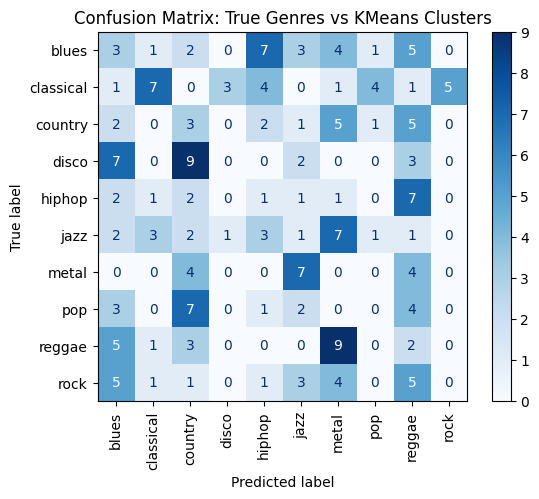

In [220]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(true_labels_enc, predicted_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(xticks_rotation='vertical', cmap='Blues')
plt.title("Confusion Matrix: True Genres vs KMeans Clusters")
plt.show()

In [224]:
from scipy.optimize import linear_sum_assignment

def cluster_accuracy(y_true, y_pred):
    D = max(y_pred.max(), y_true.max()) + 1
    cost_matrix = np.zeros((D, D), dtype=np.int64)
    for i in range(len(y_pred)):
        cost_matrix[y_pred[i], y_true[i]] += 1
    row_ind, col_ind = linear_sum_assignment(cost_matrix.max() - cost_matrix)
    return cost_matrix[row_ind, col_ind].sum() / len(y_pred)

acc = cluster_accuracy(true_labels_enc, predicted_labels)
print(f"KMeans Clustering Accuracy (after best match): {acc:.2%}")

KMeans Clustering Accuracy (after best match): 28.00%


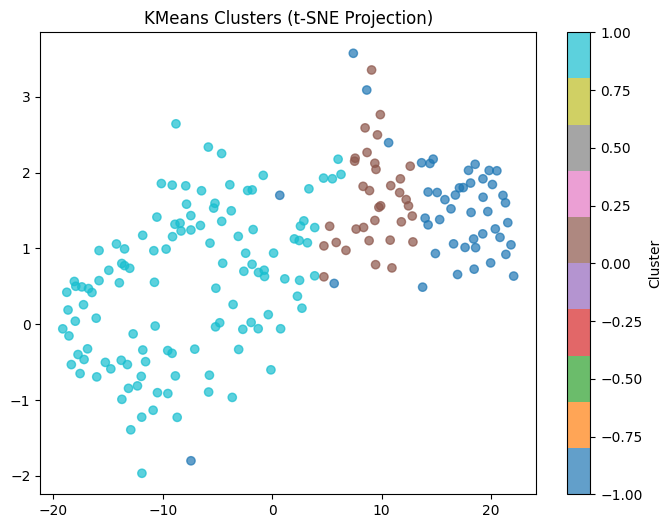

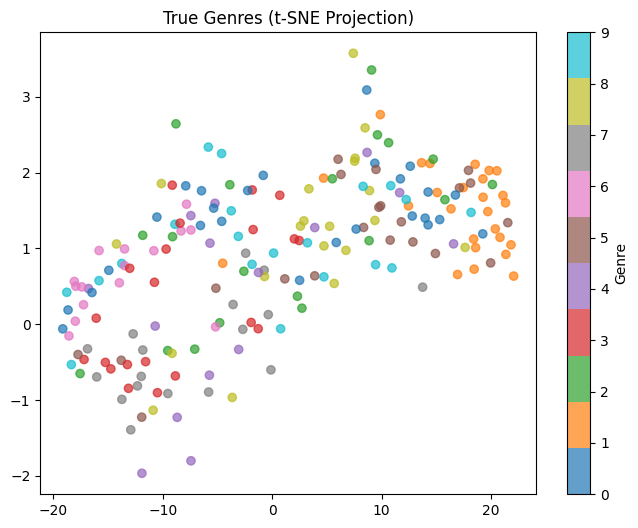

In [205]:
from sklearn.manifold import TSNE

X_2d = TSNE(n_components=2, random_state=42).fit_transform(spectrograms_reduced)

plt.figure(figsize=(8, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=predicted_labels, cmap='tab10', alpha=0.7)
plt.title("KMeans Clusters (t-SNE Projection)")
plt.colorbar(label='Cluster')
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=true_labels_enc, cmap='tab10', alpha=0.7)
plt.title("True Genres (t-SNE Projection)")
plt.colorbar(label='Genre')
plt.show()


In [32]:
with torch.no_grad():
    patches = model.embeddings(spec)
    outputs = model.encoder(patches, output_hidden_states=True)
    embeddings = outputs.hidden_states[-1]  # (1, num_patches, hidden_dim)
    embedding= embeddings.mean(dim = 1)
embeddings.shape

torch.Size([1, 1214, 768])

In [26]:
len(outputs.hidden_states)

13

In [8]:
pip install torchinfo

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.1.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
from torchinfo import summary
summary(model)

Layer (type:depth-idx)                             Param #
ASTModel                                           --
├─ASTEmbeddings: 1-1                               933,888
│    └─ASTPatchEmbeddings: 2-1                     --
│    │    └─Conv2d: 3-1                            197,376
│    └─Dropout: 2-2                                --
├─ASTEncoder: 1-2                                  --
│    └─ModuleList: 2-3                             --
│    │    └─ASTLayer: 3-2                          7,087,872
│    │    └─ASTLayer: 3-3                          7,087,872
│    │    └─ASTLayer: 3-4                          7,087,872
│    │    └─ASTLayer: 3-5                          7,087,872
│    │    └─ASTLayer: 3-6                          7,087,872
│    │    └─ASTLayer: 3-7                          7,087,872
│    │    └─ASTLayer: 3-8                          7,087,872
│    │    └─ASTLayer: 3-9                          7,087,872
│    │    └─ASTLayer: 3-10                         7,087,872
│   

In [42]:
import torch
import numpy as np
from transformers import ASTModel, ASTConfig

# Load model
model = ASTModel.from_pretrained("polinaZaroko/ast-gtzan", output_hidden_states=True)
model.eval()

# Load your spectrogram
data = np.load(r"P:\datasets\geenres\fma\fma_small\fma_small\audio\spectrograms\try.npz")
spec = data['001039/track']  # (time, mel) = (1024, 128)

# Prepare input (AST expects [batch, 1, time, mel])
spec = torch.tensor(spec, dtype=torch.float32).unsqueeze(0)  # [1, 1, T, M]

# Forward pass
with torch.no_grad():
    outputs = model(spec, output_hidden_states=True)
    
    # All hidden states (tuple of torch.FloatTensor)
    # Each element is (batch_size, sequence_length, hidden_size)
    all_hidden_states = outputs.hidden_states
    
    # You can access specific layers:
    embedding_layer_6 = all_hidden_states[6]  # 6th layer
    last_layer = all_hidden_states[-1]       # Final layer
    pooler_output = outputs.last_hidden_state.mean(dim=1)  # Average pooling

print("Number of layers:", len(all_hidden_states))
print("Embedding shape from layer 6:", embedding_layer_6.shape)
print("Final layer shape:", last_layer.shape)
print("Pooled output shape:", pooler_output.shape)

RuntimeError: The size of tensor a (1790) must match the size of tensor b (1214) at non-singleton dimension 1

In [36]:
with torch.no_grad():
    outputs = model.encoder(patches_projected, output_hidden_states=True)
    second_to_last = outputs.hidden_states[-5]  # [1, 512, 768]
    #pooled = second_to_last.mean(dim=1)         # [1, 768]

print("Embedding shape:", second_to_last.shape)

Embedding shape: torch.Size([1, 752, 768])


In [ ]:

data = np.load(r"P:\datasets\geenres\fma\fma_small\fma_small\audio\spectrograms\try.npz")
lst = data.files
print(lst)
#spec = np.load(r"C:\Polina\master\thesis\beat_this\data\audio\spectrograms\gtzan_old\gtzan_rock_00001\track.npy")

#spec = data["smc_193/track"]
spec = data['001039/track']
target_time = 1020
if spec.shape[0] > target_time:
    spec = spec[:target_time, :]
spec = torch.tensor(spec, dtype=torch.float32).unsqueeze(0)
spec.shape


['001039/track', '001039/track_ps-1', '001039/track_ps1', '001039/track_ts-1', '001039/track_ts1', '001039/track_ns1', '001039/track_ns2', '001039/track_ns3', '001039/track_ns4', '001039/track_ns5', '001040/track', '001040/track_ps-1', '001040/track_ps1', '001040/track_ts-1', '001040/track_ts1', '001040/track_ns1', '001040/track_ns2', '001040/track_ns3', '001040/track_ns4', '001040/track_ns5', '001066/track', '001066/track_ps-1', '001066/track_ps1', '001066/track_ts-1', '001066/track_ts1', '001066/track_ns1', '001066/track_ns2', '001066/track_ns3', '001066/track_ns4', '001066/track_ns5']


torch.Size([1, 1020, 128])

In [6]:
with torch.no_grad():
    outputs = model(spec, output_hidden_states = True)
    hidden_states = outputs.hidden_states

In [15]:
last_layer = hidden_states[-4]   # shape: (batch_size, sequence_length, hidden_size)
last_layer.shape

torch.Size([1, 1214, 768])

# evaluating the model

In [5]:
gtzan_genres = [
    "blues",
    "classical",
    "country",
    "disco",
    "hiphop",
    "jazz",
    "metal",
    "pop",
    "reggae",
    "rock"
]
dict_gtzan = {i : genre for i, genre in enumerate(gtzan_genres)}

In [6]:
dict_gtzan

{0: 'blues',
 1: 'classical',
 2: 'country',
 3: 'disco',
 4: 'hiphop',
 5: 'jazz',
 6: 'metal',
 7: 'pop',
 8: 'reggae',
 9: 'rock'}

In [1]:
from transformers import ASTForAudioClassification

model = ASTForAudioClassification.from_pretrained("polinaZaroko/ast-gtzan")
model.eval()  # set to evaluation mode


c:\Polina\master\thesis\annotations\hugginggf\Lib\site-packages\huggingface_hub\file_download.py:896: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


ASTForAudioClassification(
  (audio_spectrogram_transformer): ASTModel(
    (embeddings): ASTEmbeddings(
      (patch_embeddings): ASTPatchEmbeddings(
        (projection): Conv2d(1, 768, kernel_size=(16, 16), stride=(10, 10))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ASTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ASTLayer(
          (attention): ASTAttention(
            (attention): ASTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (output): ASTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ASTIntermediate(
            (de

In [2]:
#data = np.load(r"C:\Polina\master\thesis\beat_this\data\smc\smc.npz")
import numpy as np
data = np.load(r"P:\datasets\geenres\fma\fma_small\fma_small\audio\spectrograms\fma_001.npz")
lst = data.files
print(lst)

['001039/track', '001039/track_ps-1', '001039/track_ps1', '001039/track_ts-1', '001039/track_ts1', '001040/track', '001040/track_ps-1', '001040/track_ps1', '001040/track_ts-1', '001040/track_ts1', '001066/track', '001066/track_ps-1', '001066/track_ps1', '001066/track_ts-1', '001066/track_ts1', '001069/track', '001069/track_ps-1', '001069/track_ps1', '001069/track_ts-1', '001069/track_ts1', '001073/track', '001073/track_ps-1', '001073/track_ps1', '001073/track_ts-1', '001073/track_ts1', '001075/track', '001075/track_ps-1', '001075/track_ps1', '001075/track_ts-1', '001075/track_ts1', '001082/track', '001082/track_ps-1', '001082/track_ps1', '001082/track_ts-1', '001082/track_ts1', '001083/track', '001083/track_ps-1', '001083/track_ps1', '001083/track_ts-1', '001083/track_ts1', '001087/track', '001087/track_ps-1', '001087/track_ps1', '001087/track_ts-1', '001087/track_ts1', '001102/track', '001102/track_ps-1', '001102/track_ps1', '001102/track_ts-1', '001102/track_ts1', '001193/track', '00

In [26]:
import torch
import numpy as np
#spec = np.load(r"C:\Polina\master\thesis\beat_this\data\audio\spectrograms\gtzan_old\gtzan_rock_00001\track.npy")

#spec = data["smc_193/track"]
spec = data['001925/track']
target_time = 1020
if spec.shape[0] > target_time:
    spec = spec[:target_time, :]
spec = torch.tensor(spec, dtype=torch.float32).unsqueeze(0)
spec.shape


torch.Size([1, 1020, 128])

In [27]:
with torch.no_grad():
    logits = model(input_values = spec).logits
    predicted_id = logits.argmax(dim = -1).item()
#predict_label = model.config
dict_gtzan[predicted_id]


'country'

# Uploading fma dataset to check the model

In [30]:
import pandas as pd
dataset_fma = pd.read_csv(r"C:\Polina\master\thesis\beat_this\data\fma_metadata\tracks.csv")
#dataset_genres = dataset_fma[["track_id"]]
#dataset_fma.head()

C:\Users\polin\AppData\Local\Temp\ipykernel_5796\74948495.py:2: DtypeWarning: Columns (0,1,5,6,21,22,34,38,39,49,55,56,57,58,59) have mixed types. Specify dtype option on import or set low_memory=False.
  dataset_fma = pd.read_csv(r"C:\Polina\master\thesis\beat_this\data\fma_metadata\tracks.csv")


In [4]:
dataset_fma["Unnamed: 0"].values

array([nan, 'track_id', '2', ..., 155318, 155319, 155320],
      shape=(106576,), dtype=object)

In [104]:
dataset_fma.head(10)

,track_id,comments,date_created,date_released,engineer,favorites,id,information,listens,producer,...,publisher,tags,title,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,track_id,comments,date_created,date_released,engineer,favorites,id,information,listens,producer,...,publisher,tags,title,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,0,2008-11-26 01:44:45,2009-01-05 00:00:00,NaN,4,1,<p></p>,6073,NaN,...,NaN,[],Food,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,0,2008-11-26 01:44:45,2009-01-05 00:00:00,NaN,4,1,<p></p>,6073,NaN,...,NaN,[],Electric Ave,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,0,2008-11-26 01:44:45,2009-01-05 00:00:00,NaN,4,1,<p></p>,6073,NaN,...,NaN,[],This World,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,10,0,2008-11-26 01:45:08,2008-02-06 00:00:00,NaN,4,6,NaN,47632,NaN,...,NaN,[],Freeway,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,20,0,2008-11-26 01:45:05,2009-01-06 00:00:00,NaN,2,4,"<p> ""spiritual songs"" from Nicky Cook</p>",2710,NaN,...,NaN,[],Spiritual Level,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,26,0,2008-11-26 01:45:05,2009-01-06 00:00:00,NaN,2,4,"<p> ""spiritual songs"" from Nicky Cook</p>",2710,NaN,...,NaN,[],Where is your Love?,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,30,0,2008-11-26 01:45:05,2009-01-06 00:00:00,NaN,2,4,"<p> ""spiritual songs"" from Nicky Cook</p>",2710,NaN,...,NaN,[],Too Happy,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,46,0,2008-11-26 01:45:05,2009-01-06 00:00:00,NaN,2,4,"<p> ""spiritual songs"" from Nicky Cook</p>",2710,NaN,...,NaN,[],Yosemite,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
dataset_fma.columns = dataset_fma.iloc[0]    # fixing the columns and format of the dataset
dataset_fm= dataset_fma[1:]
dataset_fma.reset_index(drop= True, inplace=True)

In [111]:
dataset_genres = dataset_fma[["track_id", "title","genre_top","duration"]]   # picking only important columns

In [113]:
dataset_genres = dataset_genres.drop(1)  # droping NA

In [116]:
dataset_genres.head(10)

,track_id,title,title,genre_top,duration
2,2,AWOL - A Way Of Life,Food,Hip-Hop,168
3,3,AWOL - A Way Of Life,Electric Ave,Hip-Hop,237
4,5,AWOL - A Way Of Life,This World,Hip-Hop,206
5,10,Constant Hitmaker,Freeway,Pop,161
6,20,Niris,Spiritual Level,NaN,311
7,26,Niris,Where is your Love?,NaN,181
8,30,Niris,Too Happy,NaN,174
9,46,Niris,Yosemite,NaN,104
10,48,Niris,Light of Light,NaN,205
11,134,AWOL - A Way Of Life,Street Music,Hip-Hop,207


In [115]:
dataset_genres= dataset_genres[1:]

In [64]:
import os
from pathlib import Path
#all_folders = []
all_tracks = []
path = Path(r"C:\Polina\master\thesis\beat_this\data\fma_small\fma_small")
for file in os.listdir(path):
    #print(file)
    full_path = os.path.join(path, file)
    if os.path.isdir(full_path):
        #all_folders.append(full_path)
        for track in os.listdir(full_path):
            id = int(track[:-4])
            all_tracks.append(id)

In [66]:
len(all_tracks)

8000

In [96]:
dataset_genres["track_id"].values

array([     2,      3,      5, ..., 155318, 155319, 155320],
      shape=(106574,))

In [97]:
filtered_df = dataset_genres[dataset_genres["track_id"].isin(all_tracks)]

In [100]:
filtered_df.isna().sum()

0
track_id      0
title         1
title         5
genre_top     0
duration     48
dtype: int64

In [102]:
filtered_df.to_csv(os.path.join(path, "tracks_small.csv"))

In [120]:
filtered_df["genre_top"].value_counts().to_dict()

{'Instrumental': 1000,
 'Rock': 999,
 'International': 998,
 'Folk': 994,
 'Electronic': 992,
 'Hip-Hop': 989,
 'Experimental': 987,
 'Pop': 986,
 '1': 9,
 '3': 8,
 '4': 6,
 '0': 6,
 '2': 5,
 '5': 5,
 '7': 2,
 '8': 2,
 '305': 1,
 '261': 1,
 '13': 1,
 '11': 1,
 '21': 1,
 '144': 1,
 '12': 1,
 '77': 1,
 '243': 1,
 '6': 1,
 '14': 1,
 '16': 1}

In [94]:
dataset_genres["track_id"] = pd.to_numeric(dataset_genres["track_id"])

In [ ]:
import numpy as np
import pandas as pd
dataset_fma = pd.read_csv(r"P:\datasets\geenres\fma\fma_small\fma_small\tracks_small.csv")

Index(['Unnamed: 0', 'track_id', 'title', 'title.1', 'genre_top', 'duration'], dtype='object')

In [7]:
genres = ['Instrumental',  'Rock', 'International',  'Folk', 'Electronic', 'Hip-Hop', 'Experimental', 'Pop']
dataset_fma_filtered = dataset_fma[dataset_fma["genre_top"].isin( genres)]

In [14]:
dataset_fma_filtered["genre_top"].value_counts().to_dict()

{'Instrumental': 1000,
 'Rock': 999,
 'International': 998,
 'Folk': 994,
 'Electronic': 992,
 'Hip-Hop': 989,
 'Experimental': 987,
 'Pop': 986}

In [12]:
dataset_fma_filtered.to_csv(r"P:\datasets\geenres\fma\fma_small\fma_small\tracks_small_filtered.csv")

In [15]:
dataset_fma_filtered.head(15)

,Unnamed: 0,track_id,title,title.1,genre_top,duration
0,0,2,AWOL - A Way Of Life,Food,Hip-Hop,168
1,1,5,AWOL - A Way Of Life,This World,Hip-Hop,206
2,2,10,Constant Hitmaker,Freeway,Pop,161
3,3,140,The Blind Spot,Queen Of The Wires,Folk,253
4,4,141,Every Man For Himself,Ohio,Folk,182
5,5,148,Contradiction,Blackout 2,Experimental,138
6,6,182,Worn Copy,Jules Lost His Jewels,Rock,228
7,7,190,Blue Piano,Castle Of Stars,Folk,249
8,8,193,Blue Piano,Here With You,Folk,254
9,9,194,Blue Piano,All I want to Do,Folk,192


# dataset file for creating spectrograms from fma


In [19]:
import pandas as pd
dataset_path = pd.read_csv(r"C:\Polina\master\thesis\annotations\dataset_paths.csv")
dataset_path

,fma_000,P:\datasets\geenres\fma\fma_small\fma_small\000


In [2]:
dataset_path_fma = {"title": [], "path": []}

In [3]:
import os
from pathlib import Path
all_folders = []
path_fma = Path(r"P:\datasets\geenres\fma\fma_small\fma_small")
for dir in os.listdir(path_fma):
    dir_path = os.path.join(path_fma, dir)
    if os.path.isdir(dir_path) and dir != "try":
        dataset_path_fma["title"].append("fma_" + str(dir))
        dataset_path_fma["path"].append(dir_path)

In [8]:
import pandas as pd
dataset_path_fma = pd.DataFrame.from_dict(dataset_path_fma)

In [9]:
dataset_path_fma

,title,path
0,fma_000,P:\datasets\geenres\fma\fma_small\fma_small\000
1,fma_001,P:\datasets\geenres\fma\fma_small\fma_small\001
2,fma_002,P:\datasets\geenres\fma\fma_small\fma_small\002
3,fma_003,P:\datasets\geenres\fma\fma_small\fma_small\003
4,fma_004,P:\datasets\geenres\fma\fma_small\fma_small\004
...,...,...
151,fma_151,P:\datasets\geenres\fma\fma_small\fma_small\151
152,fma_152,P:\datasets\geenres\fma\fma_small\fma_small\152
153,fma_153,P:\datasets\geenres\fma\fma_small\fma_small\153
154,fma_154,P:\datasets\geenres\fma\fma_small\fma_small\154


In [11]:
dataset_path_fma.to_csv("dataset_paths_fma.csv", index = False)